In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('insurance.csv')
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830
1334,18,female,31.920,0,no,northeast,2205.98080
1335,18,female,36.850,0,no,southeast,1629.83350
1336,21,female,25.800,0,no,southwest,2007.94500


In [3]:
# check duplicated row
df.duplicated().sum()

np.int64(1)

In [4]:
# drop duplicated row
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [5]:
# check missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [6]:
# check data type
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1337 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1337 non-null   int64  
 1   sex       1337 non-null   object 
 2   bmi       1337 non-null   float64
 3   children  1337 non-null   int64  
 4   smoker    1337 non-null   object 
 5   region    1337 non-null   object 
 6   charges   1337 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 83.6+ KB


In [8]:
df.describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


In [9]:
# Seperate X and y
X = df.drop(columns='charges')
y= df['charges']

In [10]:
X.head(3)

,age,sex,bmi,children,smoker,region
0,19,female,27.90,0,yes,southwest
1,18,male,33.77,1,no,southeast
2,28,male,33.00,3,no,southeast


In [11]:
y.head(3)

0    16884.9240
1     1725.5523
2     4449.4620
Name: charges, dtype: float64

In [12]:
# Split data 8:2
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=88)


In [13]:
X_train.shape

(1069, 6)

In [14]:
y_train.shape

(1069,)

In [15]:
X_test.shape

(268, 6)

In [16]:
y_test.shape

(268,)

In [17]:
# Data preprocessing and building pipeline

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression

numeric_features = ['age', 'bmi', 'children']
categorical_features = ['sex', 'smoker', 'region']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'),
     categorical_features)
])
# StandardScaler changes data to have mean = 0 and standard deviation = 1
# Uses one hot encoder for sex, smoker, and region column because all of them does not represent order

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

In [18]:
# Training model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['age', 'bmi', 'children']),
                                                 ('cat',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['sex', 'smoker',
                                                   'region'])])),
                ('regressor', LinearRegression())])

In [19]:
# Prediction
y_pred = model.predict(X_test)

In [20]:
# Results

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE : {mae:.2f}")
print(f"MSE : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² : {r2:.4f}")

MAE : 4390.80
MSE : 41824492.10
RMSE : 6467.19
R² : 0.7361


In [21]:
feature_names = model.named_steps['preprocessor'].get_feature_names_out()
print(feature_names)

['num__age' 'num__bmi' 'num__children' 'cat__sex_male' 'cat__smoker_yes'
 'cat__region_northwest' 'cat__region_southeast' 'cat__region_southwest']


In [22]:
print(model.named_steps['regressor'].coef_)

[ 3492.58383187  2035.53410544   654.86940452  -310.01029073
 23738.91071685  -504.9329885  -1083.90124236 -1132.54169144]


In [23]:
comparison = pd.DataFrame({
    'Actual': y_test,
    'Prediction': y_pred,
    'Difference': y_test - y_pred
})
comparison.head(10)

,Actual,Prediction,Difference
889,11945.13270,13686.766961,-1741.634261
41,4949.75870,8502.894856,-3553.136156
678,12363.54700,14712.850289,-2349.303289
226,2689.49540,6845.890219,-4156.394819
1100,16776.30405,27978.848333,-11202.544283
1050,8023.13545,11877.772183,-3854.636733
1091,11286.53870,12199.528657,-912.989957
750,19539.24300,29243.350655,-9704.107655
2,4449.46200,6777.948290,-2328.486290
82,37165.16380,29488.195917,7676.967883


<Axes: title={'center': 'Residual from Actual Value and Predicted Value'}, xlabel='Difference/Residual', ylabel='Frequency'>

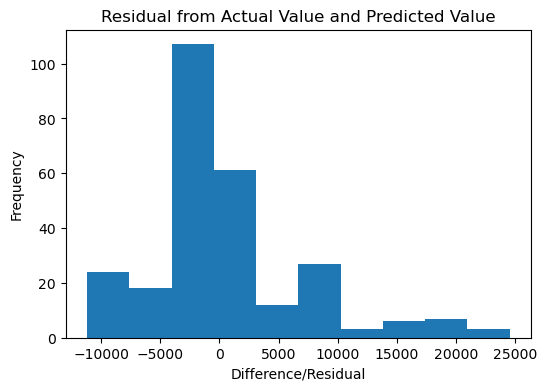

In [35]:
comparison.Difference.plot(kind='hist', xlabel='Difference/Residual', figsize=(6,4), 
                           title='Residual from Actual Value and Predicted Value')

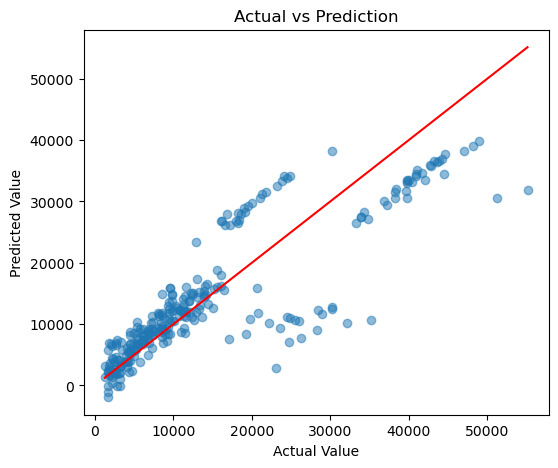

In [25]:
# Using scatter plot to visualize the model result
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')  # ideal line
plt.xlabel('Actual Value')
plt.ylabel('Predicted Value')
plt.title('Actual vs Prediction')
plt.show()

Insights:
- Model performs quite well for values under 18000, but struggles at values over 18000
- Model predicted some values to be negative which doesn't make sense